## Predictive Coding Modules

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- Predictive Coding Modules ---

class CorticalColumn:
    """
    A simple predictive-coding-inspired cortical column.
    역할: 뇌의 피질 기둥(cortical column)을 흉내 내는 클래스
    W: 하위(입력)과 상위(은닉) 표현을 잇는 가중치 행렬로, 예측 모델의 파라미터를 저장
    """
    def __init__(self, input_dim, latent_dim):
        self.W = np.random.randn(input_dim, latent_dim) * 0.1

    # inference is the forward pass of the network
    # x is the input data
    # num_iters is the number of iterations to run the inference
    # lr_h is the learning rate for the hidden layer
    # returns the hidden layer and the error
    """
    초기값 h=0: 상위 표현(은닉 변수)을 0으로 초기화
    반복(iterative inference):
    x_hat = h Wᵀ 로 “하위 입력 예측”
    e = x – x_hat 으로 예측 오차 계산
    h ← h + lr_h · (e W) 로 오차가 줄어들도록 은닉 표현을 조정
    이론과 연관:
    상향전달(feedforward)은 오차 신호 e
    하향전달(feedback)은 예측 x_hat
    두 신호의 반복적 조정을 통해 오차를 최소화
    """
    def inference(self, x, num_iters=10, lr_h=0.1):
        batch_size = x.shape[0]
        h = np.zeros((batch_size, self.W.shape[1]))
        for _ in range(num_iters):
            x_hat = h @ self.W.T
            e = x - x_hat
            h += lr_h * (e @ self.W)
        return h, e

    # update_weights is the backward pass of the network
    # x is the input data
    # h is the hidden layer
    # lr_w is the learning rate for the weights
    """
    가중치 학습:
    은닉 표현 h 가 “좋은” 예측을 할 수 있도록 W 를 조금씩 보정
    실제론 예측 코딩에서는 오차에 기반한 동시 업데이트(rule)가 더 복잡하지만, 여기선 간단한 경사상승 형태
    """
    def update_weights(self, x, h, lr_w=1e-3):
        dW = x.T @ h / x.shape[0]
        self.W += lr_w * dW

class HierarchicalPCNetwork:
    """
    Two-layer predictive coding network:
      Column1: x -> h1
      Column2: h1 -> h2
    """
    # input_dim is the dimension of the input data
    # hidden_dim is the dimension of the hidden layer
    # top_dim is the dimension of the top layer
    """
    1층(col1): 입력 x → 은닉 h1
    2층(col2): 은닉 h1 → 최상위 표현 h2    
    """
    def __init__(self, input_dim, hidden_dim, top_dim):
        self.col1 = CorticalColumn(input_dim, hidden_dim)
        self.col2 = CorticalColumn(hidden_dim, top_dim)

    # train is the training loop of the network
    # x_data is the input data
    # epochs is the number of epochs to run the training
    """
    하위층에서 은닉 h1 추론
    그 결과로 최상위층 은닉 h2 추론
    두 가중치를 각 계층별로 업데이트
    이론:
    예측 코딩 네트워크는 계층마다 예측과 오차를 교환하며, 각 계층이 동시에 “자신의 상위 계층이 보내는 예측”을 좇아 조정
    여기선 순차적으로 inference → weight‐update 를 수행
    """
    def train(self, x_data, epochs=100):
        for epoch in range(epochs):
            h1, _ = self.col1.inference(x_data, num_iters=15, lr_h=0.05)
            h2, _ = self.col2.inference(h1, num_iters=15, lr_h=0.05)
            self.col1.update_weights(x_data, h1, lr_w=5e-4)
            self.col2.update_weights(h1, h2, lr_w=5e-4)

    # reconstruct is the reconstruction pass of the network
    # x is the input data
    # returns the hidden layer and the top layer
    def reconstruct(self, x):
        h1, _ = self.col1.inference(x, num_iters=15, lr_h=0.05)
        h2, _ = self.col2.inference(h1, num_iters=15, lr_h=0.05)
        return h1, h2


## Visualize Predictive Code

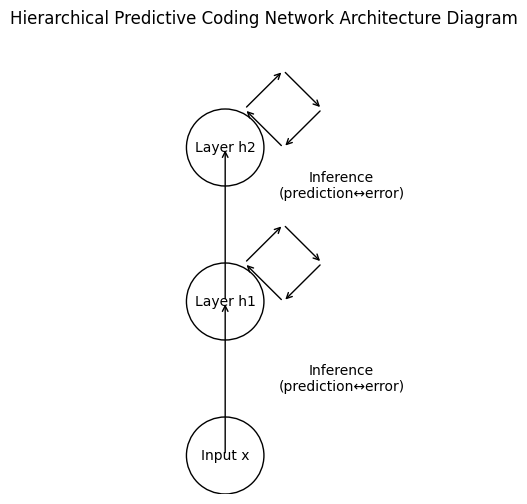

In [4]:
import matplotlib.pyplot as plt

# Create a simple diagram for the hierarchical predictive coding network
fig, ax = plt.subplots(figsize=(6, 6))

# Define node positions
positions = {
    'Input x': (0.5, 0.1),
    'Layer h1': (0.5, 0.5),
    'Layer h2': (0.5, 0.9)
}

# Draw nodes
for label, (x, y) in positions.items():
    circle = plt.Circle((x, y), 0.1, fill=False)
    ax.add_patch(circle)
    ax.text(x, y, label, ha='center', va='center')

# Draw arrows between layers
ax.annotate('', xy=positions['Layer h1'], xytext=positions['Input x'],
            arrowprops=dict(arrowstyle='->'))
ax.annotate('', xy=positions['Layer h2'], xytext=positions['Layer h1'],
            arrowprops=dict(arrowstyle='->'))

# Draw iterative inference loops at each layer
# Loop at h1
ax.annotate('', xy=(0.65, 0.5), xytext=(0.75, 0.6),
            arrowprops=dict(arrowstyle='->'))
ax.annotate('', xy=(0.75, 0.6), xytext=(0.65, 0.7),
            arrowprops=dict(arrowstyle='->'))
ax.annotate('', xy=(0.65, 0.7), xytext=(0.55, 0.6),
            arrowprops=dict(arrowstyle='->'))
ax.annotate('', xy=(0.55, 0.6), xytext=(0.65, 0.5),
            arrowprops=dict(arrowstyle='->'))

# Loop at h2
ax.annotate('', xy=(0.65, 0.9), xytext=(0.75, 1.0),
            arrowprops=dict(arrowstyle='->'))
ax.annotate('', xy=(0.75, 1.0), xytext=(0.65, 1.1),
            arrowprops=dict(arrowstyle='->'))
ax.annotate('', xy=(0.65, 1.1), xytext=(0.55, 1.0),
            arrowprops=dict(arrowstyle='->'))
ax.annotate('', xy=(0.55, 1.0), xytext=(0.65, 0.9),
            arrowprops=dict(arrowstyle='->'))

# Annotate processes
ax.text(0.8, 0.3, "Inference\n(prediction↔error)", ha='center', va='center')
ax.text(0.8, 0.8, "Inference\n(prediction↔error)", ha='center', va='center')

# Formatting
ax.set_xlim(0, 1.2)
ax.set_ylim(0, 1.2)
ax.axis('off')
ax.set_title("Hierarchical Predictive Coding Network Architecture Diagram")

plt.show()


## Simulation Realistic Sensor Data

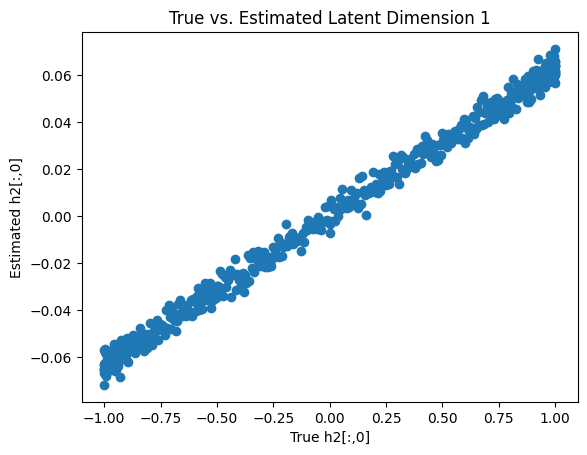

Sample inputs (first 3):
[[ 3.87   1.514  1.408 -1.506 -1.145  2.747]
 [ 3.489  1.679  1.369 -1.518 -1.153  2.572]
 [ 3.616  1.701  1.434 -1.568 -1.281  2.72 ]]

Reconstructed inputs (first 3):
[[ 0.789  0.292  0.389  0.044 -0.266  0.145]
 [ 0.735  0.277  0.365  0.045 -0.256  0.14 ]
 [ 0.764  0.289  0.38   0.048 -0.272  0.148]]


In [ ]:
np.random.seed(42)
num_samples = 500

# Latent factors: time-of-day cycle (2 dims) + seasonal trend (1 dim)
t = np.linspace(0, 24, num_samples)                 # hours
time_cycle = np.stack([np.sin(2*np.pi*t/24), np.cos(2*np.pi*t/24)], axis=1)
season_trend = np.sin(np.linspace(0, 2*np.pi, num_samples))[:, None]
h2_true = np.concatenate([time_cycle, season_trend], axis=1)  # (500, 3)

# Define true weight projections
input_dim = 6
hidden_dim = 5
top_dim = 3
W2_true = np.random.randn(hidden_dim, top_dim)
W1_true = np.random.randn(input_dim, hidden_dim)

# Generate hierarchical data: h2_true -> h1_true -> x_data
h1_true = h2_true @ W2_true.T + 0.05 * np.random.randn(num_samples, hidden_dim)
x_data = h1_true @ W1_true.T + 0.05 * np.random.randn(num_samples, input_dim)

# --- Train Predictive Coding Network ---

net = HierarchicalPCNetwork(input_dim, hidden_dim, top_dim)
net.train(x_data, epochs=100)

# --- Reconstruction and Visualization ---

# Reconstruct latents from inputs
h1_est, h2_est = net.reconstruct(x_data)

# Plot true vs. estimated top-layer latents
plt.figure()
plt.scatter(h2_true[:,0], h2_est[:,0])
plt.title("True vs. Estimated Latent Dimension 1")
plt.xlabel("True h2[:,0]")
plt.ylabel("Estimated h2[:,0]")
plt.show()

# Show sample input vs reconstruction for first 3 samples
h1_sample, _ = net.col1.inference(x_data[:3])
x_hat_sample = h1_sample @ net.col1.W.T

print("Sample inputs (first 3):")
print(np.round(x_data[:3], 3))
print("\nReconstructed inputs (first 3):")
print(np.round(x_hat_sample, 3))